# TSMC Topology Cache Inspector (Full Version)
Verify TSMC SPI-based topology cache for GNN dataset generation

**Purpose**: 
- Check TSMC full_graph topology cache structure and adjacency matrices
- Verify node feature generation via `apply_topology_to_sample`

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add path for imports
sys.path.insert(0, '/home/tkdgn2907/Deepsets_test/MAML/Projects/data_processing/gnn/topology_cache')

# Set style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

## 1. Load TSMC Full Graph Topology Cache

In [2]:
# Load TSMC full graph cache
tsmc_cache_path = "/home/tkdgn2907/Deepsets_test/MAML/Projects/data_processing/gnn/topology_cache/cell_topology_cache_tsmc_tcbn28hpcplusbwp30p140_110a_lpe_typical.pth"

print(f"Loading TSMC cache from: {tsmc_cache_path}")
tsmc_cache = torch.load(tsmc_cache_path, weights_only=False)

print(f"\n✓ Loaded {len(tsmc_cache)} TSMC cells")
print(f"\nCell names:")
for i, cell_name in enumerate(sorted(tsmc_cache.keys())):
    cache = tsmc_cache[cell_name]
    has_adj = 'adjacency_matrix' in cache
    num_nodes = cache.get('num_nodes', 0)
    num_edges = cache.get('num_edges', 0)
    print(f"  [{i:2d}] {cell_name:<30s} Nodes: {num_nodes:3d}, Edges: {num_edges:4d}, Adj: {'✅' if has_adj else '❌'}")

Loading TSMC cache from: /home/tkdgn2907/Deepsets_test/MAML/Projects/data_processing/gnn/topology_cache/cell_topology_cache_tsmc_tcbn28hpcplusbwp30p140_110a_lpe_typical.pth

✓ Loaded 66 TSMC cells

Cell names:
  [ 0] AN2D0BWP30P140                 Nodes:  11, Edges:   44, Adj: ✅
  [ 1] AN2D1BWP30P140                 Nodes:  11, Edges:   44, Adj: ✅
  [ 2] AN2D2BWP30P140                 Nodes:  13, Edges:   74, Adj: ✅
  [ 3] AN3D0BWP30P140                 Nodes:  14, Edges:   62, Adj: ✅
  [ 4] AN3D1BWP30P140                 Nodes:  14, Edges:   62, Adj: ✅
  [ 5] AN4D0BWP30P140                 Nodes:  17, Edges:   82, Adj: ✅
  [ 6] AN4D1BWP30P140                 Nodes:  17, Edges:   82, Adj: ✅
  [ 7] AO211D0BWP30P140               Nodes:  17, Edges:   82, Adj: ✅
  [ 8] AO211D1BWP30P140               Nodes:  17, Edges:   82, Adj: ✅
  [ 9] AO21D0BWP30P140                Nodes:  14, Edges:   62, Adj: ✅
  [10] AO21D1BWP30P140                Nodes:  14, Edges:   62, Adj: ✅
  [11] BUFFD0BWP30P1

## 2. Verify TSMC Cache Structure

In [12]:
# Check first cell in detail
cell_name = 'DFCNQD1BWP30P140'  # NAND2 cell
cell_cache = tsmc_cache[cell_name]

print(f"📋 Inspecting TSMC cell: {cell_name}")
print("=" * 80)

print(f"\nCache structure:")
for key, value in cell_cache.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key:20s}: Tensor {list(value.shape)} dtype={value.dtype}")
    elif isinstance(value, list):
        print(f"  {key:20s}: List with {len(value)} items -> {value}")
    elif isinstance(value, dict):
        print(f"  {key:20s}: Dict with {len(value)} items")
    else:
        print(f"  {key:20s}: {type(value).__name__} = {value}")

# Verify adjacency matrix
if 'adjacency_matrix' in cell_cache:
    adj = cell_cache['adjacency_matrix']
    edge_index = cell_cache['edge_index']
    num_nodes = cell_cache['num_nodes']
    
    print(f"\n✅ Adjacency matrix found!")
    print(f"   Shape: {adj.shape}")
    print(f"   Expected shape: ({num_nodes}, {num_nodes})")
    print(f"   Non-zero entries: {adj.nonzero().shape[0]}")
    print(f"   Edge index edges: {edge_index.shape[1]}")
else:
    print(f"\n❌ No adjacency matrix in cache!")

📋 Inspecting TSMC cell: DFCNQD1BWP30P140

Cache structure:
  all_nodes           : List with 34 items -> ['VDD', 'VSS', 'Q', 'CDN', 'CP', 'D', 'XM1', 'XM10', 'XM11', 'XM12', 'XM13', 'XM14', 'XM15', 'XM16', 'XM17', 'XM18', 'XM19', 'XM2', 'XM20', 'XM21', 'XM22', 'XM23', 'XM24', 'XM25', 'XM26', 'XM27', 'XM28', 'XM3', 'XM4', 'XM5', 'XM6', 'XM7', 'XM8', 'XM9']
  external_inputs     : List with 3 items -> ['CDN', 'CP', 'D']
  power_nodes         : List with 2 items -> ['VDD', 'VSS']
  output_nodes        : List with 1 items -> ['Q']
  transistor_nodes    : List with 28 items -> ['XM1', 'XM10', 'XM11', 'XM12', 'XM13', 'XM14', 'XM15', 'XM16', 'XM17', 'XM18', 'XM19', 'XM2', 'XM20', 'XM21', 'XM22', 'XM23', 'XM24', 'XM25', 'XM26', 'XM27', 'XM28', 'XM3', 'XM4', 'XM5', 'XM6', 'XM7', 'XM8', 'XM9']
  intermediate_nets   : List with 0 items -> []
  edge_index          : Tensor [2, 278] dtype=torch.int64
  edge_attr           : Tensor [278, 3] dtype=torch.float32
  adjacency_matrix    : Tensor [34, 34]

## 3. Verify Transistor Information

In [13]:
# Check transistor info for the cell
cell_name = 'DFCNQD1BWP30P140'
cell_cache = tsmc_cache[cell_name]

print(f"📋 Transistor Information: {cell_name}")
print("=" * 80)

print(f"\nTransistor nodes: {cell_cache['transistor_nodes']}")
print(f"\nTransistor details:")
for trans_name, info in cell_cache['transistor_info'].items():
    trans_type = 'NMOS' if info['type'] == 1.0 else 'PMOS'
    print(f"  {trans_name}: {trans_type}")
    print(f"      Width: {info['width']:.3f} um")
    print(f"      Gate:   {info['gate']}")
    print(f"      Source: {info['source']}")
    print(f"      Drain:  {info['drain']}")
    print()

📋 Transistor Information: DFCNQD1BWP30P140

Transistor nodes: ['XM1', 'XM10', 'XM11', 'XM12', 'XM13', 'XM14', 'XM15', 'XM16', 'XM17', 'XM18', 'XM19', 'XM2', 'XM20', 'XM21', 'XM22', 'XM23', 'XM24', 'XM25', 'XM26', 'XM27', 'XM28', 'XM3', 'XM4', 'XM5', 'XM6', 'XM7', 'XM8', 'XM9']

Transistor details:
  XM1: NMOS
      Width: 0.280 um
      Gate:   CDN
      Source: 
      Drain:  VSS

  XM10: NMOS
      Width: 0.120 um
      Gate:   
      Source: 
      Drain:  

  XM11: NMOS
      Width: 0.185 um
      Gate:   
      Source: 
      Drain:  

  XM12: NMOS
      Width: 0.185 um
      Gate:   D
      Source: VSS
      Drain:  

  XM13: NMOS
      Width: 0.140 um
      Gate:   
      Source: VSS
      Drain:  

  XM14: NMOS
      Width: 0.140 um
      Gate:   CP
      Source: 
      Drain:  VSS

  XM15: PMOS
      Width: 0.340 um
      Gate:   CDN
      Source: 
      Drain:  VDD

  XM16: PMOS
      Width: 0.340 um
      Gate:   
      Source: VDD
      Drain:  Q

  XM17: PMOS
      Width: 

## 4. Test Node Feature Generation (apply_topology_to_sample)

In [14]:
# Import apply_topology_to_sample function
from precompute_cell_topology import apply_topology_to_sample

# Test parameters (typical TSMC values)
cell_name = 'DFCNQD1BWP30P140'
voltage = 0.9  # V
input_slew = 0.01  # ns
output_load = 0.001  # pF
output_value = 0.05  # ns (target delay)

print(f"📋 Testing Node Feature Generation")
print("=" * 80)
print(f"\nTest parameters:")
print(f"  Cell: {cell_name}")
print(f"  Voltage: {voltage} V")
print(f"  Input slew: {input_slew} ns")
print(f"  Output load: {output_load} pF")
print(f"  Output value: {output_value} ns")

# Generate node features
try:
    graph_sample = apply_topology_to_sample(
        tsmc_cache,
        cell_name,
        voltage,
        input_slew,
        output_load,
        output_value
    )
    
    print(f"\n✅ Node features generated successfully!")
    print(f"\nGraph sample keys: {list(graph_sample.keys())}")
    
    node_features = graph_sample['node_features']
    all_nodes = graph_sample['all_nodes']
    
    print(f"\nNode features shape: {node_features.shape}")
    print(f"Expected shape: ({len(all_nodes)}, 7)")
    
except Exception as e:
    print(f"\n❌ Error generating node features: {e}")
    import traceback
    traceback.print_exc()

📋 Testing Node Feature Generation

Test parameters:
  Cell: DFCNQD1BWP30P140
  Voltage: 0.9 V
  Input slew: 0.01 ns
  Output load: 0.001 pF
  Output value: 0.05 ns

✅ Node features generated successfully!

Graph sample keys: ['all_nodes', 'node_features']

Node features shape: torch.Size([34, 7])
Expected shape: (34, 7)


## 5. Detailed Node Feature Analysis

In [15]:
# Detailed node feature analysis
cell_name = 'DFCNQD1BWP30P140'
cell_cache = tsmc_cache[cell_name]

graph_sample = apply_topology_to_sample(
    tsmc_cache,
    cell_name,
    voltage=0.9,
    input_slew=0.01,
    output_load=0.001,
    output_value=0.05
)

node_features = graph_sample['node_features']
all_nodes = graph_sample['all_nodes']

print(f"📋 Detailed Node Feature Analysis: {cell_name}")
print("=" * 100)
print(f"\nNode Feature Format: [is_power, is_port, trans_type, width, voltage, input_slew, output_load]")
print(f"  - is_power: 1.0 for VDD/VSS, 0.0 otherwise")
print(f"  - is_port: 1.0 for input/output ports, 0.0 for transistors")
print(f"  - trans_type: 1.0 for NMOS, -1.0 for PMOS, 0.0 for non-transistor")
print(f"  - width: transistor width in um")
print(f"  - voltage: operating voltage")
print(f"  - input_slew: for input ports only")
print(f"  - output_load: for output ports only")
print("\n" + "-" * 100)

print(f"\n{'Node':<10s} {'Type':<12s} {'is_power':>10s} {'is_port':>10s} {'trans_type':>12s} {'width':>10s} {'voltage':>10s} {'slew':>10s} {'load':>10s}")
print("-" * 100)

transistor_nodes = cell_cache['transistor_nodes']
power_nodes = cell_cache['power_nodes']
output_nodes = cell_cache['output_nodes']
external_inputs = cell_cache['external_inputs']

for i, (node, features) in enumerate(zip(all_nodes, node_features)):
    # Determine node type
    if node in power_nodes:
        node_type = "Power"
    elif node in output_nodes:
        node_type = "Output"
    elif node in external_inputs:
        node_type = "Input"
    elif node in transistor_nodes:
        trans_info = cell_cache['transistor_info'].get(node, {})
        node_type = "NMOS" if trans_info.get('type', 0) == 1.0 else "PMOS"
    else:
        node_type = "Other"
    
    f = features.tolist()
    print(f"{node:<10s} {node_type:<12s} {f[0]:>10.1f} {f[1]:>10.1f} {f[2]:>12.1f} {f[3]:>10.3f} {f[4]:>10.2f} {f[5]:>10.4f} {f[6]:>10.5f}")

📋 Detailed Node Feature Analysis: DFCNQD1BWP30P140

Node Feature Format: [is_power, is_port, trans_type, width, voltage, input_slew, output_load]
  - is_power: 1.0 for VDD/VSS, 0.0 otherwise
  - is_port: 1.0 for input/output ports, 0.0 for transistors
  - trans_type: 1.0 for NMOS, -1.0 for PMOS, 0.0 for non-transistor
  - width: transistor width in um
  - voltage: operating voltage
  - input_slew: for input ports only
  - output_load: for output ports only

----------------------------------------------------------------------------------------------------

Node       Type           is_power    is_port   trans_type      width    voltage       slew       load
----------------------------------------------------------------------------------------------------
VDD        Power               1.0        0.0          0.0      0.000       0.90     0.0000    0.00000
VSS        Power               1.0        0.0          0.0      0.000       0.90     0.0000    0.00000
Q          Output         

## 6. Verify Node Features for Multiple Cells

In [7]:
# Test node feature generation for multiple cells
test_cells = ['INVD1BWP30P140', 'ND2D1BWP30P140', 'NR2D1BWP30P140', 'AN2D1BWP30P140', 'OR2D1BWP30P140', 'XOR2D1BWP30P140']
test_cells = [c for c in test_cells if c in tsmc_cache]

print(f"📋 Node Feature Generation Test for Multiple Cells")
print("=" * 80)

results = []
for cell_name in test_cells:
    try:
        graph_sample = apply_topology_to_sample(
            tsmc_cache,
            cell_name,
            voltage=0.9,
            input_slew=0.01,
            output_load=0.001,
            output_value=0.05
        )
        
        node_features = graph_sample['node_features']
        all_nodes = graph_sample['all_nodes']
        
        # Verify shape
        expected_shape = (len(all_nodes), 7)
        shape_ok = node_features.shape == torch.Size(expected_shape)
        
        # Verify voltage is set
        voltage_ok = all(node_features[:, 4] == 0.9)
        
        # Verify no NaN
        nan_ok = not torch.isnan(node_features).any()
        
        status = '✅' if (shape_ok and voltage_ok and nan_ok) else '❌'
        results.append((cell_name, status, node_features.shape, shape_ok, voltage_ok, nan_ok))
        
    except Exception as e:
        results.append((cell_name, '❌', str(e), False, False, False))

print(f"\n{'Cell':<25s} {'Status':^8s} {'Shape':<15s} {'Shape OK':^10s} {'Voltage OK':^12s} {'No NaN':^10s}")
print("-" * 85)
for r in results:
    if isinstance(r[2], torch.Size):
        print(f"{r[0]:<25s} {r[1]:^8s} {str(list(r[2])):<15s} {'✅' if r[3] else '❌':^10s} {'✅' if r[4] else '❌':^12s} {'✅' if r[5] else '❌':^10s}")
    else:
        print(f"{r[0]:<25s} {r[1]:^8s} ERROR: {r[2]}")

all_passed = all(r[1] == '✅' for r in results)
print(f"\n{'='*85}")
print(f"{'✅ ALL CELLS PASSED' if all_passed else '❌ SOME CELLS FAILED'}")

📋 Node Feature Generation Test for Multiple Cells

Cell                       Status  Shape            Shape OK   Voltage OK    No NaN  
-------------------------------------------------------------------------------------
INVD1BWP30P140               ✅     [6, 7]              ✅           ✅           ✅     
ND2D1BWP30P140               ✅     [9, 7]              ✅           ✅           ✅     
NR2D1BWP30P140               ✅     [9, 7]              ✅           ✅           ✅     
AN2D1BWP30P140               ✅     [11, 7]             ✅           ✅           ✅     
OR2D1BWP30P140               ✅     [11, 7]             ✅           ✅           ✅     
XOR2D1BWP30P140              ✅     [17, 7]             ✅           ✅           ✅     

✅ ALL CELLS PASSED


## 7. Visualize Node Features

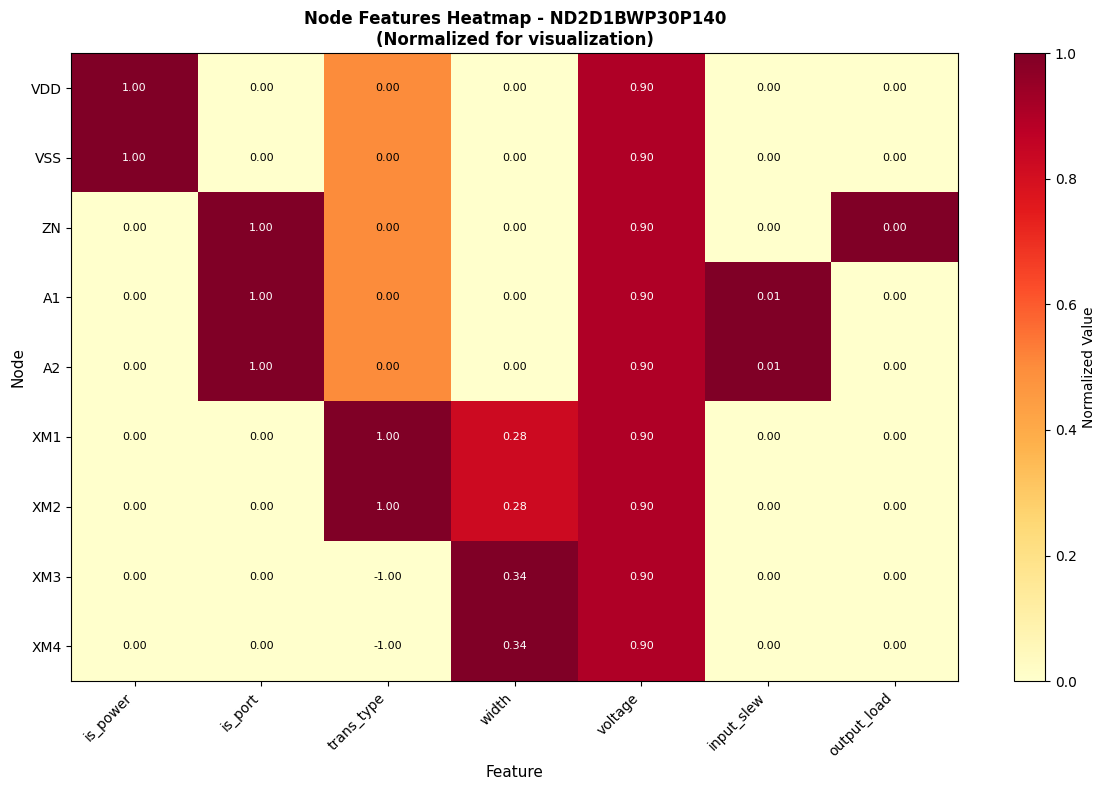

In [8]:
# Visualize node features as heatmap
cell_name = 'ND2D1BWP30P140'

graph_sample = apply_topology_to_sample(
    tsmc_cache,
    cell_name,
    voltage=0.9,
    input_slew=0.01,
    output_load=0.001,
    output_value=0.05
)

node_features = graph_sample['node_features'].numpy()
all_nodes = graph_sample['all_nodes']

feature_names = ['is_power', 'is_port', 'trans_type', 'width', 'voltage', 'input_slew', 'output_load']

fig, ax = plt.subplots(figsize=(12, 8))

# Normalize for visualization (except voltage which is constant)
node_features_viz = node_features.copy()
for i in range(node_features_viz.shape[1]):
    col = node_features_viz[:, i]
    if col.max() != col.min():
        node_features_viz[:, i] = (col - col.min()) / (col.max() - col.min())

im = ax.imshow(node_features_viz, cmap='YlOrRd', aspect='auto')
ax.set_title(f'Node Features Heatmap - {cell_name}\n(Normalized for visualization)', fontsize=12, fontweight='bold')

ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(all_nodes)))
ax.set_yticklabels(all_nodes, fontsize=10)

ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Node', fontsize=11)

# Add value annotations
for i in range(len(all_nodes)):
    for j in range(len(feature_names)):
        val = node_features[i, j]
        text = f'{val:.2f}' if abs(val) < 10 else f'{val:.1f}'
        color = 'white' if node_features_viz[i, j] > 0.5 else 'black'
        ax.text(j, i, text, ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, label='Normalized Value')
plt.tight_layout()
plt.show()

## 8. Visualize Adjacency Matrix

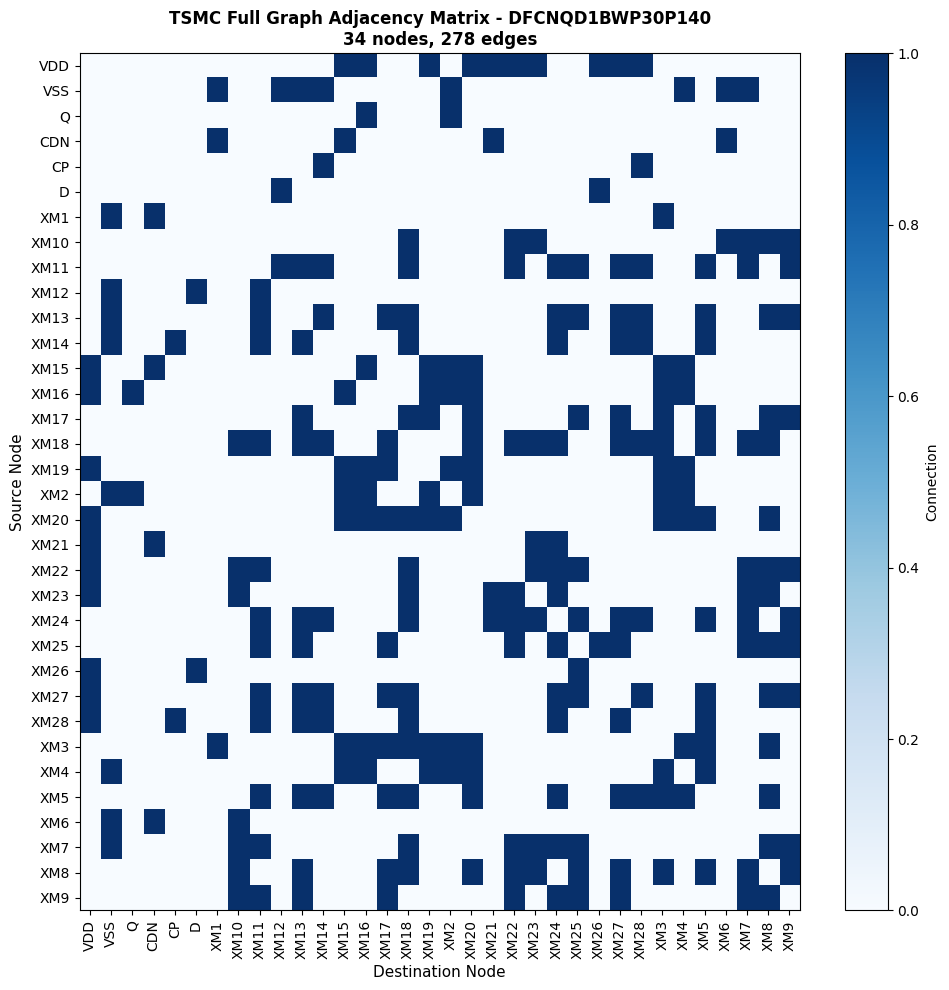


Node list: ['VDD', 'VSS', 'Q', 'CDN', 'CP', 'D', 'XM1', 'XM10', 'XM11', 'XM12', 'XM13', 'XM14', 'XM15', 'XM16', 'XM17', 'XM18', 'XM19', 'XM2', 'XM20', 'XM21', 'XM22', 'XM23', 'XM24', 'XM25', 'XM26', 'XM27', 'XM28', 'XM3', 'XM4', 'XM5', 'XM6', 'XM7', 'XM8', 'XM9']
Power nodes: ['VDD', 'VSS']
Output nodes: ['Q']
Input nodes: ['CDN', 'CP', 'D']
Transistor nodes: ['XM1', 'XM10', 'XM11', 'XM12', 'XM13', 'XM14', 'XM15', 'XM16', 'XM17', 'XM18', 'XM19', 'XM2', 'XM20', 'XM21', 'XM22', 'XM23', 'XM24', 'XM25', 'XM26', 'XM27', 'XM28', 'XM3', 'XM4', 'XM5', 'XM6', 'XM7', 'XM8', 'XM9']


In [16]:
# Visualize TSMC adjacency matrix
cell_name = 'DFCNQD1BWP30P140'  # NAND2
cell_cache = tsmc_cache[cell_name]

if 'adjacency_matrix' in cell_cache:
    adj = cell_cache['adjacency_matrix']
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    im = ax.imshow(adj.numpy(), cmap='Blues', aspect='auto', interpolation='nearest')
    ax.set_title(f'TSMC Full Graph Adjacency Matrix - {cell_name}\n'
                 f'{adj.shape[0]} nodes, {adj.nonzero().shape[0]} edges',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Destination Node', fontsize=11)
    ax.set_ylabel('Source Node', fontsize=11)
    plt.colorbar(im, ax=ax, label='Connection')
    
    # Add node labels
    all_nodes = cell_cache['all_nodes']
    ax.set_xticks(range(len(all_nodes)))
    ax.set_xticklabels(all_nodes, rotation=90, fontsize=10)
    ax.set_yticks(range(len(all_nodes)))
    ax.set_yticklabels(all_nodes, fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nNode list: {all_nodes}")
    print(f"Power nodes: {cell_cache['power_nodes']}")
    print(f"Output nodes: {cell_cache['output_nodes']}")
    print(f"Input nodes: {cell_cache['external_inputs']}")
    print(f"Transistor nodes: {cell_cache['transistor_nodes']}")
else:
    print("❌ No adjacency matrix to visualize!")

## 9. Compare with ASAP7 (Optional)

In [10]:
# Load ASAP7 cache for comparison
asap7_cache_path = "./topology_cache/cell_topology_cache_asap7sc7p5t_28_L.pth"

try:
    asap7_cache = torch.load(asap7_cache_path, weights_only=False)
    print(f"✓ Loaded ASAP7 cache with {len(asap7_cache)} cells")
    
    # Compare structure
    asap7_cell = list(asap7_cache.values())[0]
    tsmc_cell = list(tsmc_cache.values())[0]
    
    print(f"\n📊 Structure Comparison:")
    print(f"{'Key':<25s} {'ASAP7':^15s} {'TSMC':^15s} {'Match':^10s}")
    print("-" * 65)
    
    all_keys = set(asap7_cell.keys()) | set(tsmc_cell.keys())
    for key in sorted(all_keys):
        asap7_has = '✅' if key in asap7_cell else '❌'
        tsmc_has = '✅' if key in tsmc_cell else '❌'
        match = '✅' if (key in asap7_cell) == (key in tsmc_cell) else '❌'
        print(f"{key:<25s} {asap7_has:^15s} {tsmc_has:^15s} {match:^10s}")
    
    # Compare transistor naming
    print(f"\n📊 Transistor Naming Comparison:")
    print(f"  ASAP7: {asap7_cell['transistor_nodes'][:3]}...")
    print(f"  TSMC:  {tsmc_cell['transistor_nodes'][:3]}...")
    
except FileNotFoundError:
    print(f"⚠️ ASAP7 cache not found at {asap7_cache_path}")
    print("Skipping comparison...")

✓ Loaded ASAP7 cache with 160 cells

📊 Structure Comparison:
Key                            ASAP7           TSMC         Match   
-----------------------------------------------------------------
adjacency_matrix                 ✅               ✅            ✅     
all_nodes                        ✅               ✅            ✅     
edge_attr                        ✅               ✅            ✅     
edge_index                       ✅               ✅            ✅     
external_inputs                  ✅               ✅            ✅     
intermediate_nets                ✅               ✅            ✅     
num_edges                        ✅               ✅            ✅     
num_nodes                        ✅               ✅            ✅     
output_nodes                     ✅               ✅            ✅     
power_nodes                      ✅               ✅            ✅     
transistor_info                  ✅               ✅            ✅     
transistor_nodes                 ✅           

## 10. Summary Statistics

In [11]:
print("=" * 100)
print("TSMC TOPOLOGY CACHE VERIFICATION SUMMARY")
print("=" * 100)

# Count cells with adjacency matrices
cells_with_adj = sum(1 for cell in tsmc_cache.values() if 'adjacency_matrix' in cell)

# Node/edge statistics
node_counts = [cell['num_nodes'] for cell in tsmc_cache.values()]
edge_counts = [cell['num_edges'] for cell in tsmc_cache.values()]

print(f"\n📊 TSMC Full Graph Cache:")
print(f"   Total cells: {len(tsmc_cache)}")
print(f"   Cells with adjacency_matrix: {cells_with_adj}")
print(f"   Coverage: {cells_with_adj/len(tsmc_cache)*100:.1f}%")
print(f"   Status: {'✅ ALL CELLS HAVE ADJACENCY MATRIX' if cells_with_adj == len(tsmc_cache) else '❌ MISSING ADJACENCY MATRICES'}")

print(f"\n📊 Node Statistics:")
print(f"   Min nodes: {min(node_counts)}")
print(f"   Max nodes: {max(node_counts)}")
print(f"   Avg nodes: {np.mean(node_counts):.1f}")

print(f"\n📊 Edge Statistics:")
print(f"   Min edges: {min(edge_counts)}")
print(f"   Max edges: {max(edge_counts)}")
print(f"   Avg edges: {np.mean(edge_counts):.1f}")

# Transistor naming check
sample_cell = list(tsmc_cache.values())[0]
trans_naming = sample_cell['transistor_nodes'][0] if sample_cell['transistor_nodes'] else 'N/A'
print(f"\n📊 Transistor Naming:")
print(f"   Format: {trans_naming} (original TSMC naming preserved)")

# Node feature test
print(f"\n📊 Node Feature Generation:")
test_passed = 0
for cell_name in list(tsmc_cache.keys())[:10]:
    try:
        graph_sample = apply_topology_to_sample(
            tsmc_cache, cell_name, 0.9, 0.01, 0.001, 0.05
        )
        if graph_sample['node_features'].shape[1] == 7:
            test_passed += 1
    except:
        pass
print(f"   Tested cells: 10")
print(f"   Passed: {test_passed}")
print(f"   Status: {'✅ NODE FEATURE GENERATION WORKING' if test_passed == 10 else '❌ NODE FEATURE GENERATION FAILED'}")

print(f"\n{'=' * 100}")
if cells_with_adj == len(tsmc_cache) and test_passed == 10:
    print("✅ VERIFICATION PASSED: TSMC topology cache is properly structured and functional!")
else:
    print("❌ VERIFICATION FAILED: Some issues detected!")
print("=" * 100)

TSMC TOPOLOGY CACHE VERIFICATION SUMMARY

📊 TSMC Full Graph Cache:
   Total cells: 66
   Cells with adjacency_matrix: 66
   Coverage: 100.0%
   Status: ✅ ALL CELLS HAVE ADJACENCY MATRIX

📊 Node Statistics:
   Min nodes: 6
   Max nodes: 44
   Avg nodes: 17.2

📊 Edge Statistics:
   Min edges: 12
   Max edges: 346
   Avg edges: 98.1

📊 Transistor Naming:
   Format: XM1 (original TSMC naming preserved)

📊 Node Feature Generation:
   Tested cells: 10
   Passed: 10
   Status: ✅ NODE FEATURE GENERATION WORKING

✅ VERIFICATION PASSED: TSMC topology cache is properly structured and functional!
